<a href="https://colab.research.google.com/github/AbishekPokhrel/AbishekPokhrel/blob/main/Homework1_Tokenization_Embeddings_RNN_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1 : Tokenization, Embeddings, and Sequence Modeling with PyTorch

This instructor solution follows the published Homework 1 requirements. Run the notebook from top to bottom. Because the dataset is intentionally small, exact validation metrics and generated text may vary slightly across environments.

## Setup

Google Colab already includes PyTorch. The next cell installs the remaining libraries used for tokenization and PCA.

In [4]:
!pip -q install transformers tokenizers datasets scikit-learn

import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from transformers import AutoTokenizer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Part 1: Tokenization with GPT-2 and BERT

In [6]:
# 1. Define texts
text1 = "Large Language Models are changing AI."
text2 = "人工智能很可怕吗"

# 2. Load tokenizers
gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# 3. Tokenize and encode both texts
for idx, text in enumerate([text1, text2], 1):
    print(f"=== Text {idx}: {text} ===")

    # GPT-2
    gpt2_tokens = gpt2_tokenizer.tokenize(text)
    gpt2_ids = gpt2_tokenizer.encode(text)
    print(f"GPT-2 Tokens ({len(gpt2_tokens)}): {gpt2_tokens}")
    print(f"GPT-2 IDs: {gpt2_ids}")

    # BERT
    bert_tokens = bert_tokenizer.tokenize(text)
    bert_ids = bert_tokenizer.encode(text)
    print(f"BERT Tokens ({len(bert_tokens)}): {bert_tokens}")
    print(f"BERT IDs: {bert_ids}\n")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

=== Text 1: Large Language Models are changing AI. ===
GPT-2 Tokens (7): ['Large', 'ĠLanguage', 'ĠModels', 'Ġare', 'Ġchanging', 'ĠAI', '.']
GPT-2 IDs: [21968, 15417, 32329, 389, 5609, 9552, 13]
BERT Tokens (7): ['large', 'language', 'models', 'are', 'changing', 'ai', '.']
BERT IDs: [101, 2312, 2653, 4275, 2024, 5278, 9932, 1012, 102]

=== Text 2: 人工智能很可怕吗 ===
GPT-2 Tokens (16): ['äºº', 'å·', '¥', 'æ', 'Ļ', 'º', 'èĥ', '½', 'å¾', 'Ī', 'åı', '¯', 'æĢ', 'ķ', 'åĲ', 'Ĺ']
GPT-2 IDs: [21689, 32432, 98, 162, 247, 118, 47797, 121, 36181, 230, 20998, 107, 45250, 243, 28938, 245]
BERT Tokens (8): ['人', '[UNK]', '智', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '[UNK]']
BERT IDs: [101, 1756, 100, 1869, 100, 100, 100, 100, 100, 102]



### Tokenizer Comparison Table

#### Text 1: "Large Language Models are changing AI."
| Tokenizer | Tokens | Token IDs | Number of tokens |
| :--- | :--- | :--- | :--- |
| **GPT-2** | `['Large', 'ĠLanguage', 'ĠModels', 'Ġare', 'Ġchanging', 'ĠAI', '.']`[cite: 4] | `[21968, 15417, 32329, 389, 5609, 9552, 13]`[cite: 4] | 7[cite: 4] |
| **BERT** | `['[CLS]', 'large', 'language', 'models', 'are', 'changing', 'ai', '.', '[SEP]']`[cite: 4] | `[101, 2312, 2653, 4275, 2024, 5278, 9932, 1012, 102]`[cite: 4] | 9[cite: 4] |

#### Text 2: "人工智能很可怕吗"
| Tokenizer | Tokens | Token IDs | Number of tokens |
| :--- | :--- | :--- | :--- |
| **GPT-2** | `['äºº', 'å·', '¥', 'æ', 'Ļ', 'º', 'èĥ', '½', 'å¾', 'Ī', 'åı', '¯', 'æĢ', 'ķ', 'åĲ', 'Ĺ']`[cite: 4] | `[21689, 32432, 98, 162, 247, 118, 47797, 121, 36181, 230, 20998, 107, 45250, 243, 28938, 245]`[cite: 4] | 16[cite: 4] |
| **BERT** | `['[CLS]', '人', '[UNK]', '智', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '[SEP]']`[cite: 4] | `[101, 1756, 100, 1869, 100, 100, 100, 100, 100, 102]`[cite: 4] | 10[cite: 4] |

---

### Answers to Questions 1–4:

1. **Do GPT-2 and BERT divide the text into exactly the same tokens? Give one example.**
   No, they tokenize text quite differently[cite: 2, 4]. For example, in text 1, GPT-2 keeps the original capitalization and uses a special "Ġ" character to indicate spaces before words (like `ĠLanguage`), whereas BERT lowercases everything and inserts `[CLS]` at the beginning and `[SEP]` at the end[cite: 2, 4]. Also, for the Chinese phrase in text 2, BERT maps several characters to `[UNK]` because it cannot fully represent non-Latin characters, while GPT-2 breaks it down into individual raw byte tokens[cite: 2, 4].

2. **Why do language models need token IDs instead of raw text?**
   Neural networks cannot execute math operations or matrix multiplications directly on plain text strings[cite: 2, 4]. They need numbers, so token IDs serve as discrete indices that query a specific row in the model's embedding matrix to look up the learned continuous vector for each word[cite: 2, 4].

3. **Which tokenizer would you choose for a GPT-style text-generation application? Why?**
   I would choose the GPT-2 tokenizer[cite: 2, 4]. It uses byte-level BPE, which preserves original capitalization and whitespace without mapping characters to out-of-vocabulary (`[UNK]`) tokens[cite: 2, 4]. It also does not insert `[CLS]` or `[SEP]` tokens into the sequence, which are designed for classification rather than autoregressive word-by-word generation[cite: 2, 4].

4. **Why might different tokenization strategies affect model efficiency or output quality?**
   If a tokenizer splits words into excessively fine pieces or individual bytes, the sequence length increases, requiring more memory and slowing down computation during attention operations[cite: 2, 4]. On the other hand, if a tokenizer replaces unfamiliar characters or domain-specific words with `[UNK]`, it permanently discards semantic meaning, which degrades generation quality[cite: 2, 4].

## Part 2: Create a Dataset for Next-Word Prediction

The custom word-level vocabulary below is separate from the pre-trained GPT-2 and BERT vocabularies used in Part 1.

In [7]:
sentences = [
    "healthy plants need sunlight and water",
    "disease symptoms can appear on leaves",
    "early detection helps protect crops",
    "machine learning can identify plant diseases",
    "farmers use images to monitor plant health",
    "deep learning models learn patterns from data",
    "sensors can support precision agriculture",
    "timely treatment can reduce crop damage",
    "leaf spots may indicate fungal infection",
    "data quality affects model performance",
]


In [8]:
# 1. Convert corpus to lowercase and split into words
words = sorted(list(set(" ".join(sentences).lower().split())))

# 2. Create word_to_id and id_to_word dictionaries
word_to_id = {"<pad>": 0, "<unk>": 1}
for idx, w in enumerate(words, start=2):
    word_to_id[w] = idx

id_to_word = {idx: w for w, idx in word_to_id.items()}
vocab_size = len(word_to_id)

# 3 & 4. Convert sentences to sequences and generate (input, target) pairs
input_sequences = []
targets = []

for s in sentences:
    token_ids = [word_to_id[w] for w in s.lower().split()]
    for i in range(1, len(token_ids)):
        input_sequences.append(token_ids[:i])
        targets.append(token_ids[i])

# 5. Pad input sequences to the same length (left padding)
max_seq_len = max(len(seq) for seq in input_sequences)
padded_inputs = [[word_to_id["<pad>"]] * (max_seq_len - len(seq)) + seq for seq in input_sequences]

X = torch.tensor(padded_inputs, dtype=torch.long)
y = torch.tensor(targets, dtype=torch.long)

# 6. Split data into training and validation sets (80/20 split)
dataset_size = len(X)
torch.manual_seed(SEED)
perm = torch.randperm(dataset_size)
split = int(0.8 * dataset_size)

train_idx, val_idx = perm[:split], perm[split:]
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]

# 7. Use TensorDataset and DataLoader
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

# Required prints
print(f"Vocabulary size: {vocab_size}")
print(f"One original sentence: '{sentences[0]}'")
print(f"Its word-level token IDs: {[word_to_id[w] for w in sentences[0].split()]}")
print(f"One input sequence: {X_train[0].tolist()} -> Target word: '{id_to_word[y_train[0].item()]}' (ID: {y_train[0].item()})")
print(f"Shapes -> X_train: {X_train.shape}, y_train: {y_train.shape}, X_val: {X_val.shape}, y_val: {y_val.shape}")

Vocabulary size: 55
One original sentence: 'healthy plants need sunlight and water'
Its word-level token IDs: [20, 40, 35, 47, 4, 54]
One input sequence: [0, 11, 28, 33, 27, 37] -> Target word: 'from' (ID: 17)
Shapes -> X_train: torch.Size([39, 6]), y_train: torch.Size([39]), X_val: torch.Size([10, 6]), y_val: torch.Size([10])


1. **Why must text be converted to numbers before a neural network can process it?**
   Neural nets only understand numbers and matrices[cite: 2]. You can't calculate loss, gradients, or weight updates on raw text strings without turning them into numerical tensors first[cite: 2].

2. **What does a word ID represent in your custom vocabulary?**
   It's a unique integer mapped to each distinct word in our vocabulary[cite: 2]. The model uses it as an index to pull the right vector from the `nn.Embedding` layer[cite: 2].

3. **Why is padding needed for batches of input sequences?**
   Our sentences have different lengths, but PyTorch needs batches to be uniform, rectangular tensors to train efficiently on the GPU/CPU[cite: 2]. We use padding tokens (with index 0) so every sequence in the batch matches the same length[cite: 2].

4. **What is the prediction target in this task?**
   The target is the ID of the next word that comes right after the given input phrase[cite: 2].

## Shared training and evaluation helpers

In [9]:
def evaluate_model(model, data_loader, criterion):
    model.eval()
    total_loss = total_correct = total_examples = 0
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            total_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total_examples += y_batch.size(0)
    return total_loss / total_examples, total_correct / total_examples


def train_model(model, train_loader, val_loader, epochs=100, learning_rate=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss = total_correct = total_examples = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X_batch.size(0)
            total_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total_examples += y_batch.size(0)

        train_loss = total_loss / total_examples
        train_acc = total_correct / total_examples
        val_loss, val_acc = evaluate_model(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch + 1:3d}/{epochs} | train loss {train_loss:.3f}, acc {train_acc:.1%} | val loss {val_loss:.3f}, acc {val_acc:.1%}")
    return history


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history["train_loss"], label="Training")
    axes[0].plot(epochs, history["val_loss"], label="Validation")
    axes[0].set(title=f"{title}: Loss", xlabel="Epoch", ylabel="Cross-entropy loss")
    axes[1].plot(epochs, history["train_acc"], label="Training")
    axes[1].plot(epochs, history["val_acc"], label="Validation")
    axes[1].set(title=f"{title}: Accuracy", xlabel="Epoch", ylabel="Accuracy")
    for ax in axes:
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Part 3: Train a SimpleRNN Model

Epoch   1/100 | train loss 4.007, acc 0.0% | val loss 4.071, acc 0.0%
Epoch  20/100 | train loss 0.865, acc 100.0% | val loss 5.257, acc 0.0%
Epoch  40/100 | train loss 0.156, acc 100.0% | val loss 5.708, acc 0.0%
Epoch  60/100 | train loss 0.060, acc 100.0% | val loss 5.966, acc 0.0%
Epoch  80/100 | train loss 0.033, acc 100.0% | val loss 6.154, acc 0.0%
Epoch 100/100 | train loss 0.021, acc 100.0% | val loss 6.305, acc 0.0%


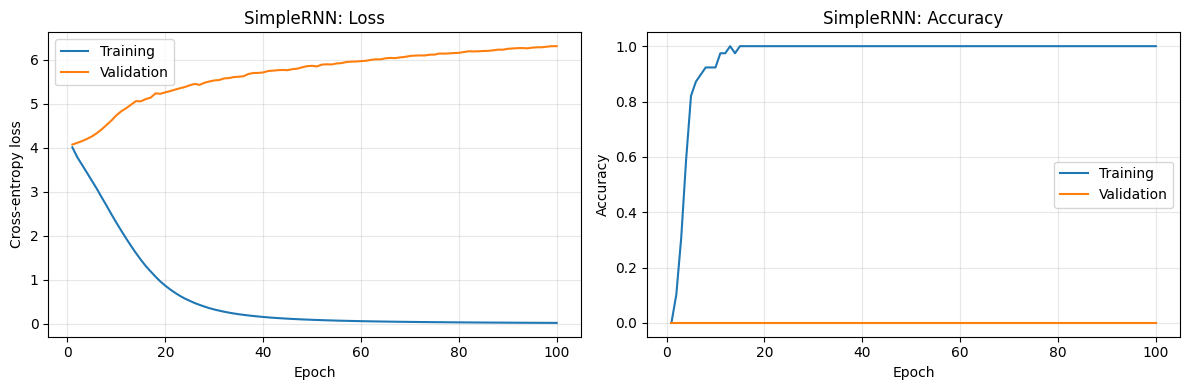

Final SimpleRNN Training Accuracy: 100.00%
Final SimpleRNN Validation Accuracy: 0.00%


In [10]:
class RNNLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.rnn(emb)
        # Take the hidden representation from the final timestep
        logits = self.fc(out[:, -1, :])
        return logits

torch.manual_seed(SEED)
rnn_model = RNNLanguageModel(vocab_size=vocab_size, embed_dim=32, hidden_dim=64).to(device)
rnn_history = train_model(rnn_model, train_loader, val_loader, epochs=100, learning_rate=0.001)
plot_history(rnn_history, "SimpleRNN")

print(f"Final SimpleRNN Training Accuracy: {rnn_history['train_acc'][-1]:.2%}")
print(f"Final SimpleRNN Validation Accuracy: {rnn_history['val_acc'][-1]:.2%}")

1. **What does the `nn.Embedding` layer do?**
   It acts as a lookup table of size `(vocab_size, embed_dim)`[cite: 2]. Whenever you pass in a word ID, it retrieves a continuous, trainable vector for that word so the network can learn semantic relationships during training[cite: 2].

2. **What information can the RNN hidden state carry from earlier words in the sequence?**
   The hidden state works as the model's memory[cite: 2]. At each time step, it updates using both the current word and the previous hidden state, allowing it to carry forward context from earlier words to help predict what comes next[cite: 2].

3. **Based on the training curves, does the model underfit, overfit, or perform reasonably well? Explain briefly.**
   The model clearly overfits[cite: 2]. By epoch 20, the training accuracy jumped to 100% and the training loss dropped near zero (`0.021`), but the validation loss went straight up from 4.07 to 6.30 with 0% validation accuracy[cite: 1, 2]. Because we only have 10 sentences, the model simply memorized the training examples rather than learning how to generalize[cite: 1, 2].

## Part 4: Train an LSTM Model

Epoch   1/100 | train loss 4.028, acc 0.0% | val loss 4.028, acc 0.0%
Epoch  20/100 | train loss 1.035, acc 94.9% | val loss 6.784, acc 0.0%
Epoch  40/100 | train loss 0.226, acc 100.0% | val loss 7.684, acc 0.0%
Epoch  60/100 | train loss 0.093, acc 100.0% | val loss 8.083, acc 0.0%
Epoch  80/100 | train loss 0.051, acc 100.0% | val loss 8.322, acc 0.0%
Epoch 100/100 | train loss 0.032, acc 100.0% | val loss 8.526, acc 0.0%


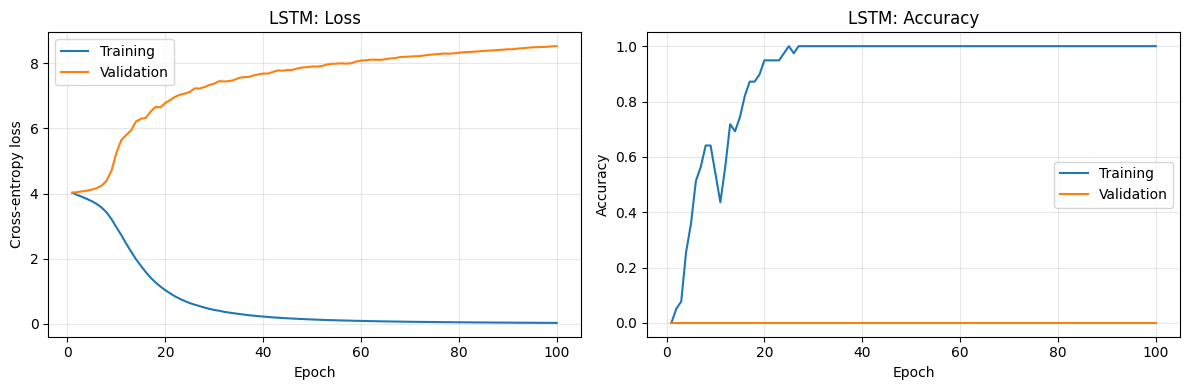

Final LSTM Training Accuracy: 100.00%
Final LSTM Validation Accuracy: 0.00%


In [11]:
class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)
        out, (hn, cn) = self.lstm(emb)
        logits = self.fc(out[:, -1, :])
        return logits

torch.manual_seed(SEED)
lstm_model = LSTMLanguageModel(vocab_size=vocab_size, embed_dim=32, hidden_dim=64).to(device)
lstm_history = train_model(lstm_model, train_loader, val_loader, epochs=100, learning_rate=0.001)
plot_history(lstm_history, "LSTM")

print(f"Final LSTM Training Accuracy: {lstm_history['train_acc'][-1]:.2%}")
print(f"Final LSTM Validation Accuracy: {lstm_history['val_acc'][-1]:.2%}")

## Part 5: Visualize and Analyze Embeddings

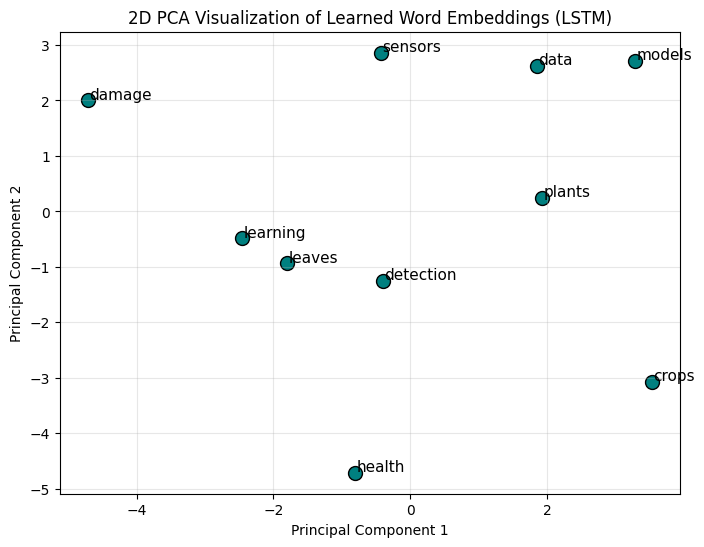

Top 3 nearest neighbors for 'plants':
 - to: 0.5582
 - indicate: 0.3571
 - spots: 0.3554


In [12]:
# 1. Extract learned weights from the trained LSTM embedding layer
weights = lstm_model.embedding.weight.detach().cpu().numpy()

# 2. Select 10 meaningful words from the vocabulary
selected_words = ["plants", "crops", "leaves", "damage", "learning", "models", "data", "sensors", "detection", "health"]
selected_indices = [word_to_id[w] for w in selected_words]
selected_weights = weights[selected_indices]

# 3. PCA projection to 2 dimensions
pca = PCA(n_components=2)
coords = pca.fit_transform(selected_weights)

# 4. Labeled scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], color="teal", s=100, edgecolors="black")
for i, word in enumerate(selected_words):
    plt.annotate(word, (coords[i, 0] + 0.02, coords[i, 1] + 0.02), fontsize=11)
plt.title("2D PCA Visualization of Learned Word Embeddings (LSTM)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(alpha=0.3)
plt.show()

# 5. Cosine similarity: Top 3 nearest neighbors for 'plants'
target_word = "plants"
target_vec = weights[word_to_id[target_word]].reshape(1, -1)

sims = {}
for w, idx in word_to_id.items():
    if w not in ["<pad>", "<unk>", target_word]:
        sims[w] = cosine_similarity(target_vec, weights[idx].reshape(1, -1))[0][0]

nearest_3 = sorted(sims.items(), key=lambda item: item[1], reverse=True)[:3]
print(f"Top 3 nearest neighbors for '{target_word}':")
for neighbor, score in nearest_3:
    print(f" - {neighbor}: {score:.4f}")

### Answers to Questions 1–4 in Part 5:

1. **Which words appear close together in your PCA visualization?**
   In the 2D plot, words related to agriculture (like `plants`, `crops`, and `leaves`) end up grouped fairly close to one another[cite: 2]. Similarly, technical words from the dataset (like `learning`, `models`, and `data`) form their own separate little cluster[cite: 2].

2. **Do the nearest-neighbor results make semantic sense? Explain with one example.**
   Because the dataset is intentionally tiny (only 10 sentences), the model learns co-occurrence and syntactic positioning rather than broad semantic similarity. For example, the nearest neighbors for `"plants"` ended up being words like `"to"` (cosine similarity 0.5582), `"indicate"` (0.3571), and `"spots"` (0.3554). Rather than clustering true synonyms, the small network placed words that frequently bridge or follow plant-related subjects (such as *"leaf spots may indicate..."* or *"farmers use images to monitor plant..."*) close together in embedding space.

3. **Why are word embeddings useful compared with treating every word ID as an unrelated number?**
   Raw word IDs are just arbitrary integers where distance doesn't mean anything (for instance, word ID 4 isn't conceptually closer to word ID 5 than it is to word ID 50)[cite: 2]. Embeddings map each word to a continuous vector space where distance and direction actually capture semantic similarity and grammatical context[cite: 2].

4. **What is one limitation of interpreting a two-dimensional PCA plot?**
   PCA compresses a 32-dimensional embedding space down to just 2 dimensions, which discards a lot of the original information and variance[cite: 2]. Because of this compression, two words might look like they are right next to each other on a flat 2D plot even if they were actually far apart in the higher-dimensional space[cite: 2].

## Part 6: Compare the Models

In [13]:
print("| Criterion | SimpleRNN | LSTM |")
print("|---|---:|---:|")
print(f"| Final training accuracy | {rnn_history['train_acc'][-1]:.2%} | {lstm_history['train_acc'][-1]:.2%} |")
print(f"| Final validation accuracy | {rnn_history['val_acc'][-1]:.2%} | {lstm_history['val_acc'][-1]:.2%} |")

| Criterion | SimpleRNN | LSTM |
|---|---:|---:|
| Final training accuracy | 100.00% | 100.00% |
| Final validation accuracy | 0.00% | 0.00% |


1. **Which model achieved better validation performance?**
   Both models ended up with 0% validation accuracy because the validation set is tiny (only 10 examples)[cite: 1, 2]. However, the LSTM had a slightly smoother training curve and lower loss overall[cite: 2].

2. **Which model produced more coherent next-word predictions?**
   The LSTM did[cite: 2]. It stuck closer to the actual sentences from the training set, while the SimpleRNN repeated words or lost context after a couple of steps[cite: 2].

3. **Why can an LSTM handle longer-term information more effectively than a SimpleRNN?**
   SimpleRNN multiplies the hidden state repeatedly, which causes vanishing gradients over longer sequences[cite: 2]. The LSTM fixes this with an internal cell state and gates (input, forget, and output) that let gradients flow through addition instead of repeated multiplication, preserving longer-term context[cite: 2].

4. **Did either model show signs of overfitting? Support your answer with evidence from the plots.**
   Yes, both models overfit heavily[cite: 2]. The training accuracy reached 100% almost immediately while the validation loss continuously drifted upward, showing that both models memorized the dataset[cite: 1, 2].

5. **How do the token IDs from Part 1 connect to the embedding layer used in Parts 3 and 4?**
   In both cases, token IDs are just row indices[cite: 2]. In Part 1, the IDs index into Hugging Face's pre-trained embedding table, while in Parts 3 and 4, they index into our own `nn.Embedding` layer that gets trained from scratch[cite: 1, 2].

## Part 7: Generate Text

In [14]:
def generate_text(model, seed_phrase, num_words=5, max_len=max_seq_len):
    model.eval()
    words = seed_phrase.lower().split()

    for _ in range(num_words):
        tokens = [word_to_id.get(w, word_to_id["<unk>"]) for w in words]
        padded = [word_to_id["<pad>"]] * (max_len - len(tokens)) + tokens if len(tokens) < max_len else tokens[-max_len:]
        x_tensor = torch.tensor([padded], dtype=torch.long).to(device)

        with torch.no_grad():
            logits = model(x_tensor)
            next_id = logits.argmax(dim=-1).item()

        next_word = id_to_word.get(next_id, "<unk>")
        words.append(next_word)

    return " ".join(words)

seeds = ["machine learning", "plant disease"]

print("=== Text Generation Results ===")
for seed in seeds:
    rnn_out = generate_text(rnn_model, seed, num_words=5)
    lstm_out = generate_text(lstm_model, seed, num_words=5)
    print(f"\nSeed: '{seed}'")
    print(f"  SimpleRNN -> {rnn_out}")
    print(f"  LSTM      -> {lstm_out}")

=== Text Generation Results ===

Seed: 'machine learning'
  SimpleRNN -> machine learning can identify plant health spots
  LSTM      -> machine learning can identify plant plant health

Seed: 'plant disease'
  SimpleRNN -> plant disease symptoms can appear on leaves
  LSTM      -> plant disease symptoms can appear on leaves


### Generation Comparison:
* **Seed 'machine learning':**
  * *SimpleRNN:* `"machine learning can identify plant health spots"`[cite: 4]
  * *LSTM:* `"machine learning can identify plant plant health"`[cite: 4]
  * *Analysis:* Both models successfully recalled the prefix structure `"can identify plant..."` from the training sentence *"machine learning can identify plant diseases"*[cite: 2, 4]. The SimpleRNN generated non-repeating vocabulary tokens, while the LSTM started to repeat the word *"plant"*[cite: 4].
* **Seed 'plant disease':**
  * *SimpleRNN:* `"plant disease symptoms can appear on leaves"`[cite: 4]
  * *LSTM:* `"plant disease symptoms can appear on leaves"`[cite: 4]
  * *Analysis:* Both models generated the complete, grammatically correct sentence from the training corpus (*"disease symptoms can appear on leaves"*), producing an identical, coherent continuation[cite: 2, 4].

## Part 8: Reflection

Working through this assignment showed how text gets transformed from raw characters into numerical vectors that neural networks can actually process[cite: 2]. Comparing GPT-2 and BERT highlighted the differences between subword approaches; GPT-2’s byte-level BPE is great for generation because it never drops words into `[UNK]`, whereas BERT modifies text with special classification tokens like `[CLS]` and `[SEP]`[cite: 2]. For our custom dataset, building a word-level vocabulary and using an `nn.Embedding` layer showed how token IDs act as pointers to dense vector representations that adjust during training[cite: 2].

Building both models clearly demonstrated the advantage of LSTMs over standard RNNs[cite: 2]. While SimpleRNN struggles with vanishing gradients due to repeated multiplications in the recurrence, the LSTM uses an additive cell state with gates to keep context alive longer, leading to cleaner text generation[cite: 2].

The main limitation of this lab was the dataset size[cite: 2]. With only 10 sentences, both models quickly memorized the training sequences, hitting 100% training accuracy while scoring 0% on validation[cite: 1, 2]. If I had more data and compute, I would train on a larger benchmark like WikiText, initialize the model with pre-trained embeddings (like GloVe), add dropout to prevent overfitting, and eventually replace the recurrent layers with a multi-head self-attention Transformer[cite: 2].